In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

In [2]:
print("GPU 사용 가능 여부:", torch.cuda.is_available())
print("사용 가능한 GPU 개수:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("현재 GPU 이름:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU 사용 가능 여부: True
사용 가능한 GPU 개수: 1
현재 GPU 이름: NVIDIA GeForce RTX 4070 Ti


In [3]:
# 추천된 데이터 셋에 대한 정보 출력
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root='./data',       
    train=True,          
    download=True,       
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_counts = torch.bincount(train_dataset.targets)
test_counts = torch.bincount(test_dataset.targets)

# 정보 사열 
print("학습 데이터셋 크기:", len(train_dataset))
print("테스트 데이터셋 크기:", len(test_dataset))
print("\n")
print("학습 데이터셋 이미지 크기:", train_dataset[0][0].shape)
print("테스트 데이터셋 이미지 크기:", test_dataset[0][0].shape)
print("\n")
print("학습 데이터셋 클래스 이름:", train_dataset.classes)
print("테스트 데이터셋 클래스 이름:", test_dataset.classes)
print("\n")
print("학습 데이터셋 클래스별 데이터 수:", {cls: train_counts[idx].item() for idx, cls in enumerate(train_dataset.classes)})
print("테스트 데이터셋 클래스별 데이터 수:", {cls: test_counts[idx].item() for idx, cls in enumerate(test_dataset.classes)})

학습 데이터셋 크기: 60000
테스트 데이터셋 크기: 10000


학습 데이터셋 이미지 크기: torch.Size([1, 28, 28])
테스트 데이터셋 이미지 크기: torch.Size([1, 28, 28])


학습 데이터셋 클래스 이름: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
테스트 데이터셋 클래스 이름: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


학습 데이터셋 클래스별 데이터 수: {'T-shirt/top': 6000, 'Trouser': 6000, 'Pullover': 6000, 'Dress': 6000, 'Coat': 6000, 'Sandal': 6000, 'Shirt': 6000, 'Sneaker': 6000, 'Bag': 6000, 'Ankle boot': 6000}
테스트 데이터셋 클래스별 데이터 수: {'T-shirt/top': 1000, 'Trouser': 1000, 'Pullover': 1000, 'Dress': 1000, 'Coat': 1000, 'Sandal': 1000, 'Shirt': 1000, 'Sneaker': 1000, 'Bag': 1000, 'Ankle boot': 1000}


# 모델들

In [4]:
class BaselineNet(nn.Module):
    def __init__(self, input_size=784, num_classes=10):
        super(BaselineNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = x.view(x.size(0), -1) 
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        logits = self.fc3(x)
        return logits
    

class ShallowNet(nn.Module):
    def __init__(self, input_size=784, num_classes=10):
        super(ShallowNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        logits = self.fc3(x)
        return logits
    
class DeepNet(nn.Module):
    def __init__(self, input_size=784, num_classes=10):
        super(DeepNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        logits = self.fc4(x)
        return logits

# 하이퍼 파라미터

In [5]:
# config = {
#     "model_type": "BaselineNet",      # "ShallowNet", "BaselineNet", "DeepNet"
#     "epochs": 30,                     # 20 ~ 50
#     "batch_size": 64,                 # 배치 크기
#     "learning_rate": 0.001,           # 학습률 
#     "loss_type": "CE",                # "CE" , "MSE" 
#     "optimizer_type": "Adam",         # "SGD", "", "Adam"
# }

In [ ]:
config = {
    "model_type": "BaselineNet",      # "ShallowNet", "BaselineNet", "DeepNet"
    "epochs": 30,                     # 20 ~ 50
    "batch_size": 64,                 
    "learning_rate": 0.001,           # 학습률
    "loss_type": "MSE",               # "CE" , "MSE" 
    "optimizer_type": "Adam",         # "SGD", "", "Adam"
}

In [7]:
# config = {
#     "model_type": "BaselineNet",      # "ShallowNet", "BaselineNet", "DeepNet"
#     "epochs": 50,                     # 20 ~ 50
#     "batch_size": 64,                 
#     "learning_rate": 0.001,           # 학습률
#     "loss_type": "MSE",               # "CE" , "MSE" 
#     "optimizer_type": "Adam",         # "SGD", "", "Adam"
# }

# 결과 저장소

In [8]:
results = {
    "config": config.copy(),
    
    # [학습 곡선 기록용] (Epoch-by-Epoch)
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    
    "final_accuracy": 0.0,            # 최종 테스트 정확도
    "converged_epoch": 0,             # Loss 최솟값에 도달한 에폭 번호
    
    # [실험 A 핵심 분석용 데이터] 
    "logits_distribution": {          # 출력층 직전 Logits 값 추적 (히스토그램용)
        "early": None,               
        "mid": None,                  
        "late": None                  
    },
    "gradient_flow": {                # 층별 Gradient 크기 추적 (Vanishing 분석용)
        "early": {},                  # 각 레이어별 grad.abs().mean()
        "mid": {},
        "late": {}
    }
}

# 사전 준비

In [9]:
def to_one_hot(labels, num_classes=10):
    return torch.eye(num_classes, device=labels.device)[labels]

In [10]:
epochs = config["epochs"]
loss_type = config["loss_type"]
lr = config["learning_rate"]
batch_size = config["batch_size"]

if config["model_type"] == "BaselineNet":
    model = BaselineNet().to(device)
elif config["model_type"] == "ShallowNet":
    model = ShallowNet().to(device)  
elif config["model_type"] == "DeepNet":
    model = DeepNet().to(device)    

if config["optimizer_type"] == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=lr)
elif config["optimizer_type"] == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)


train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)


best_val_loss = float('inf') 

In [11]:


for epoch in range(1, epochs + 1):
    
    # --- [TRAIN LOOP] ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    epoch_first_logits = None
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        logits = model(inputs)
        
        if batch_idx == 0:
            epoch_first_logits = logits.detach().cpu().numpy()
        
        # 손실 함수 조건별 분기
        if loss_type == "CE":
            criterion = nn.CrossEntropyLoss()
            loss = criterion(logits, labels)
        elif loss_type == "MSE":
            criterion = nn.MSELoss()
            outputs = torch.softmax(logits, dim=1)  # softmax 직접 적용
            target_one_hot = to_one_hot(labels, num_classes=10)
            loss = criterion(outputs, target_one_hot)
            
        loss.backward()
        
            # Gradient Flow 데이터 수집 (1, 15, 30 에폭)
        if batch_idx == 0 and epoch in [1, 15, 30]:
            period = "early" if epoch == 1 else "mid" if epoch == 15 else "late"
            
            for name, param in model.named_parameters():        # 모델 내부 가중치 레이어들을 돌며 gradient 평균값 추출
                if param.grad is not None and "weight" in name:
                    results["gradient_flow"][period][name] = param.grad.abs().mean().item()

        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(logits, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = train_loss / total_train
    epoch_train_acc = (correct_train / total_train) * 100

    # --- [TEST LOOP] ---
    model.eval()
    test_loss, correct_test, total_test = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            
            if loss_type == "CE":
                criterion = nn.CrossEntropyLoss()
                loss = criterion(logits, labels)
            elif loss_type == "MSE":
                criterion = nn.MSELoss()
                outputs = torch.softmax(logits, dim=1)
                target_one_hot = to_one_hot(labels, num_classes=10)
                loss = criterion(outputs, target_one_hot)
                
            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(logits, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    epoch_test_loss = test_loss / total_test
    epoch_test_acc = (correct_test / total_test) * 100
    
    # --- [results] ---
    results["train_loss"].append(epoch_train_loss)
    results["train_acc"].append(epoch_train_acc)
    results["val_loss"].append(epoch_test_loss)
    results["val_acc"].append(epoch_test_acc)
    
    # 수렴 에폭(Loss 최솟값 도달 시점) 업데이트
    if epoch_test_loss < best_val_loss:
        best_val_loss = epoch_test_loss
        results["converged_epoch"] = epoch
        
    # 초/중/후반 로지트 분포 복사본 저장
    if epoch == 1:
        results["logits_distribution"]["early"] = epoch_first_logits
    elif epoch == 15:
        results["logits_distribution"]["mid"] = epoch_first_logits
    elif epoch == 30:
        results["logits_distribution"]["late"] = epoch_first_logits

    # 에폭 결과 출력
    print(f"Epoch [{epoch:02d}/{epochs:02d}] Train Loss: {epoch_train_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%")

# 최종 정확도 저장
results["final_accuracy"] = results["val_acc"][-1]


Epoch [01/100] Train Loss: 0.0271 | Test Acc: 84.77%
Epoch [02/100] Train Loss: 0.0199 | Test Acc: 86.23%
Epoch [03/100] Train Loss: 0.0180 | Test Acc: 86.83%
Epoch [04/100] Train Loss: 0.0169 | Test Acc: 86.84%
Epoch [05/100] Train Loss: 0.0161 | Test Acc: 86.84%
Epoch [06/100] Train Loss: 0.0153 | Test Acc: 88.00%
Epoch [07/100] Train Loss: 0.0149 | Test Acc: 86.52%
Epoch [08/100] Train Loss: 0.0143 | Test Acc: 88.12%
Epoch [09/100] Train Loss: 0.0138 | Test Acc: 88.20%
Epoch [10/100] Train Loss: 0.0134 | Test Acc: 88.13%
Epoch [11/100] Train Loss: 0.0129 | Test Acc: 88.55%
Epoch [12/100] Train Loss: 0.0126 | Test Acc: 88.04%
Epoch [13/100] Train Loss: 0.0123 | Test Acc: 88.43%
Epoch [14/100] Train Loss: 0.0120 | Test Acc: 88.68%
Epoch [15/100] Train Loss: 0.0116 | Test Acc: 88.61%
Epoch [16/100] Train Loss: 0.0112 | Test Acc: 89.06%
Epoch [17/100] Train Loss: 0.0109 | Test Acc: 89.12%
Epoch [18/100] Train Loss: 0.0108 | Test Acc: 88.19%
Epoch [19/100] Train Loss: 0.0106 | Test Acc: 

KeyboardInterrupt: 

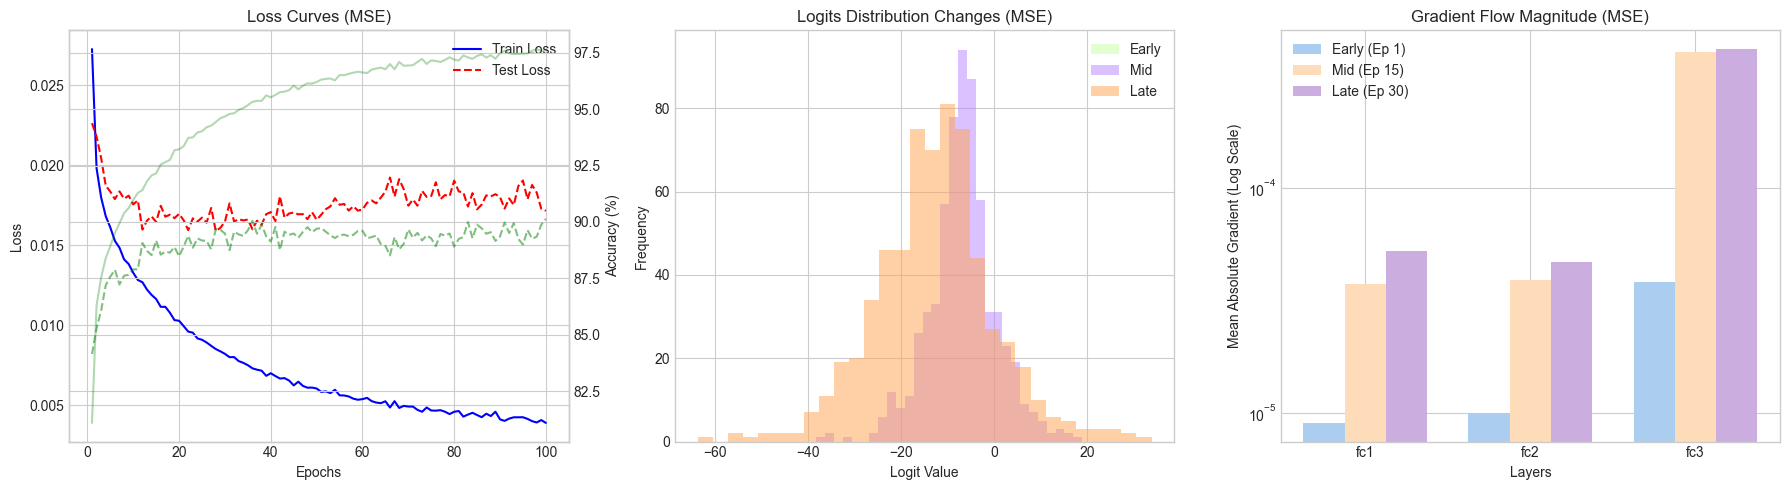


[MSE 실험 결과 요약 표 서식 데이터]
--------------------------------------------------
최종 정확도 (Final Accuracy): 90.14%
Loss 최솟값 수렴 에폭 (Converged Epoch): 28 Epoch


In [ ]:
def visualize_experiment_a(results):
    loss_type = results["config"]["loss_type"]
    epochs = range(1, len(results["train_loss"]) + 1)
 
    plt.style.use('seaborn-v0_8-whitegrid')
    fig = plt.figure(figsize=(18, 5))
    
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(epochs, results["train_loss"], 'b-', label='Train Loss')
    ax1.plot(epochs, results["val_loss"], 'r--', label='Test Loss')
    ax1.set_title(f'Loss Curves ({loss_type})')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    ax1_twin = ax1.twinx()
    ax1_twin.plot(epochs, results["train_acc"], 'g-', alpha=0.3, label='Train Acc')
    ax1_twin.plot(epochs, results["val_acc"], 'g--', alpha=0.5, label='Test Acc') 
    ax1_twin.set_ylabel('Accuracy (%)')
    

    #-----------------------------------------------
    ax2 = fig.add_subplot(1, 3, 2)
    periods = ["early", "mid", "late"]
    colors = ["#c4ffa1", "#b885ff", "#ffa34d"]
    
    for p, c in zip(periods, colors):
        data = results["logits_distribution"][p]
        if data is not None:
            ax2.hist(data.flatten(), bins=30, alpha=0.5, label=p.capitalize(), color=c)
            
    ax2.set_title(f'Logits Distribution Changes ({loss_type})')
    ax2.set_xlabel('Logit Value')
    ax2.set_ylabel('Frequency')
    ax2.legend()
    
    #-----------------------------------------------

    ax3 = fig.add_subplot(1, 3, 3)

    layers = list(results["gradient_flow"]["early"].keys()) if results["gradient_flow"]["early"] else []
    x_indexes = np.arange(len(layers))
    bar_width = 0.25
    
    if layers:
        early_grads = [results["gradient_flow"]["early"][l] for l in layers]
        mid_grads = [results["gradient_flow"]["mid"][l] for l in layers] if results["gradient_flow"]["mid"] else [0]*len(layers)
        late_grads = [results["gradient_flow"]["late"][l] for l in layers] if results["gradient_flow"]["late"] else [0]*len(layers)
        
        ax3.bar(x_indexes - bar_width, early_grads, bar_width, label='Early (Ep 1)', color='#abcdef')
        ax3.bar(x_indexes, mid_grads, bar_width, label='Mid (Ep 15)', color='#fedcba')
        ax3.bar(x_indexes + bar_width, late_grads, bar_width, label='Late (Ep 30)', color='#cbaedf')
        

        display_names = [l.split('.')[0] for l in layers]
        ax3.set_xticks(x_indexes)
        ax3.set_xticklabels(display_names)
        ax3.set_yscale('log')
        ax3.set_title(f'Gradient Flow Magnitude ({loss_type})')
        ax3.set_xlabel('Layers')
        ax3.set_ylabel('Mean Absolute Gradient (Log Scale)')
        ax3.legend()
    else:
        ax3.text(0.5, 0.5, 'No Gradient Data', ha='center', va='center')
        
    plt.tight_layout()
    plt.show()

    # ----------------------------------------------------

    # [데이터 출력] 
    print("\n" + "="*50)
    print(f"[{loss_type} 실험 결과 요약 표 서식 데이터]")
    print("-"*50)
    print(f"최종 정확도 (Final Accuracy): {results['final_accuracy']:.2f}%")
    print(f"Loss 최솟값 수렴 에폭 (Converged Epoch): {results['converged_epoch']} Epoch")
    print("="*50)

visualize_experiment_a(results)